<a href="https://colab.research.google.com/github/cristinasarakefi-art/TugasAkhirS1/blob/main/Penelitian%2011%20fix%20Untitled25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Setting tampilan visualisasi
sns.set_theme(style="whitegrid")
print("=== 1. LIBRARY BERHASIL DIIMPOR ===")

=== 1. LIBRARY BERHASIL DIIMPOR ===


In [ ]:
#Membaca Dataset dari file csv
nama_file = '/content/Data Mentah Penelitian Skripsi 5.csv'

In [ ]:
# Membaca dataset dengan pemisah titik-koma (;) dan desimal koma (,)
df = pd.read_csv(nama_file, sep=';', decimal=',')
df['Bidang Minat'] = df['Bidang Minat'].astype(str).str.strip()

print(f"\n=== 2. MEMBACA FILE DATASET '{nama_file}' ===")
print(f"Total Data Mahasiswa : {df.shape[0]} Baris")
print(f"Total Kolom Variabel : {df.shape[1]} Kolom\n")
print("5 Baris Pertama Data:")
display(df.head())


=== 2. MEMBACA FILE DATASET '/content/Data Mentah Penelitian Skripsi 5.csv' ===
Total Data Mahasiswa : 100 Baris
Total Kolom Variabel : 9 Kolom

5 Baris Pertama Data:


,Nama Lengkap,Bidang Minat,IPK Semester 3,Nilai mata kuliah Dasar Tenaga Listrik,Nilai mata kuliah Dasar Teknik Telekomunikasi,Nilai mata kuliah Dasar Pemrograman Komputer,Nilai Skor Minat TTL,Nilai Skor Minat TTT,Nilai Skor Minat TKK
0,Kristina Sara Sunia Kefi,Teknik Komputer & Kendali,2.79,A,C,C,15,15,29
1,Kartini Riyani Boni Geti,Teknik Telekomunikasi,2.79,A-,B-,C+,17,27,25
2,Fransiska Romana Dua Yustin Nellu,Teknik Telekomunikasi,2.73,A,B+,AB,30,35,32
3,JUFRIDSON LAY WOHE,Teknik Komputer & Kendali,2.48,AB,B-,C,20,7,33
4,Epin Modjo,Teknik Komputer & Kendali,2.91,B+,B-,AB,29,21,35


In [ ]:
import pandas as pd
from google.colab import data_table
from IPython.display import display, HTML

# 1. Membaca file CSV data mentah
nama_file = '/content/Data Mentah Penelitian Skripsi 5.csv'
df = pd.read_csv(nama_file, sep=';')

# 2. Kamus Konversi Nilai Huruf ke Angka (Label Encoding)
konversi_nilai = {
    'A': 4.00,
    'A-': 3.75,
    'AB': 3.50,
    'B+': 3.25,
    'B': 3.00,
    'B-': 2.75,
    'BC': 2.50,
    'C+': 2.25,
    'C': 2.00,
    'C-': 1.75,
    'D+': 1.50,
    'D': 1.00,
    'E': 0.00
}

# 3. Kolom mata kuliah yang akan di-encode
kolom_mk = [
    'Nilai mata kuliah Dasar Tenaga Listrik ',
    'Nilai mata kuliah  Dasar Teknik Telekomunikasi',
    'Nilai mata kuliah Dasar Pemrograman Komputer'
]

# 4. Memproses Label Encoding
for col in kolom_mk:
    nama_kolom_baru = col.strip() + ' (Encode)'
    df[nama_kolom_baru] = df[col].astype(str).str.strip().map(konversi_nilai)

# 5. Menyiapkan DataFrame khusus untuk tampilan tabel
kolom_tampil = ['Nama Lengkap'] + [col.strip() + ' (Encode)' for col in kolom_mk]
df_tabel = df[kolom_tampil].copy()

# Merubah nama header kolom agar lebih rapi di tabel
df_tabel.columns = ['Nama Mahasiswa', 'Nilai DTL (Encode)', 'Nilai DTT (Encode)', 'Nilai DPK (Encode)']

# 6. MENAMPILKAN DALAM BENTUK TABEL HTML INTERAKTIF (Google Colab)
print("=== TABEL HASIL LABEL ENCODING (10 DATA PERTAMA) ===")

# Mengaktifkan format tabel interaktif Colab
# Aktifkan tabel interaktif Google Colab
from google.colab import data_table
data_table.enable_dataframe_formatter()

# Tampilkan seluruh 100 data dalam bentuk tabel interaktif
display(df_tabel)

# 7. Menyimpan hasil ke file CSV baru
df.to_csv('Data_Hasil_Label_Encoding.csv', sep=';', index=False, decimal=',')
print("\n[INFO] File berhasil disimpan sebagai 'Data_Hasil_Label_Encoding.csv'")

=== TABEL HASIL LABEL ENCODING (10 DATA PERTAMA) ===


,Nama Mahasiswa,Nilai DTL (Encode),Nilai DTT (Encode),Nilai DPK (Encode)
0,Kristina Sara Sunia Kefi,4.00,2.00,2.00
1,Kartini Riyani Boni Geti,3.75,2.75,2.25
2,Fransiska Romana Dua Yustin Nellu,4.00,3.25,3.50
3,JUFRIDSON LAY WOHE,3.50,2.75,2.00
4,Epin Modjo,3.25,2.75,3.50
...,...,...,...,...
95,Tesalonika Messakh,3.50,3.75,4.00
96,Reynaldi Hadi Djo,3.00,2.50,3.50
97,Nafian Agazhi,3.50,3.75,4.00
98,Nover Morestu Ndun,4.00,4.00,4.00



[INFO] File berhasil disimpan sebagai 'Data_Hasil_Label_Encoding.csv'


In [12]:
import pandas as pd
import numpy as np
from IPython.display import display, HTML

# 1. Membaca Dataset Mentah
nama_file = '/content/Data Mentah Penelitian Skripsi 5.csv'
df = pd.read_csv(nama_file, sep=';')

# 2. Tahap 1: Label Encoding Nilai Huruf Mata Kuliah ke Angka
konversi_nilai = {
    'A': 4.00, 'A-': 3.75, 'AB': 3.50, 'B+': 3.25, 'B': 3.00,
    'B-': 2.75, 'BC': 2.50, 'C+': 2.25, 'C': 2.00, 'C-': 1.75,
    'D+': 1.50, 'D': 1.00, 'E': 0.00
}

kolom_mk = [
    'Nilai mata kuliah Dasar Tenaga Listrik ',
    'Nilai mata kuliah  Dasar Teknik Telekomunikasi',
    'Nilai mata kuliah Dasar Pemrograman Komputer'
]

encoded_cols = []
for col in kolom_mk:
    nama_enc = col.strip() + '_Encode'
    df[nama_enc] = df[col].astype(str).str.strip().map(konversi_nilai)
    encoded_cols.append(nama_enc)

# Konversi Format Teks (Koma) ke Float
df['IPK_Num'] = df['IPK Semester 3'].astype(str).str.replace(',', '.').astype(float)
df['Minat_TTL_Num'] = df['Nilai Skor Minat TTL'].astype(str).str.replace(',', '.').astype(float)
df['Minat_TTT_Num'] = df['Nilai Skor Minat TTT'].astype(str).str.replace(',', '.').astype(float)
df['Minat_TKK_Num'] = df['Nilai Skor Minat TKK'].astype(str).str.replace(',', '.').astype(float)

# Fungsi Min-Max Scaling Kustom
def min_max_scaling(series, custom_min=None, custom_max=None):
    val_min = custom_min if custom_min is not None else series.min()
    val_max = custom_max if custom_max is not None else series.max()
    if val_max == val_min:
        return series
    return (series - val_min) / (val_max - val_min)

# 3. Tahap 2: Proses Min-Max Scaling (Skala 0 sampai 1)
df['Norm_IPK_Num'] = min_max_scaling(df['IPK_Num'], 0, 4)
df['Norm_' + encoded_cols[0]] = min_max_scaling(df[encoded_cols[0]], 0, 4)
df['Norm_' + encoded_cols[1]] = min_max_scaling(df[encoded_cols[1]], 0, 4)
df['Norm_' + encoded_cols[2]] = min_max_scaling(df[encoded_cols[2]], 0, 4)

df['Norm_Minat_TTL_Num'] = min_max_scaling(df['Minat_TTL_Num'], 7, 35)
df['Norm_Minat_TTT_Num'] = min_max_scaling(df['Minat_TTT_Num'], 7, 35)
df['Norm_Minat_TKK_Num'] = min_max_scaling(df['Minat_TKK_Num'], 7, 35)

# 4. Menyusun Tabel Hasil Akhir dengan Urutan Kolom yang Rapi
kolom_hasil = [
    'Nama Lengkap',
    'Bidang Minat',
    'Norm_IPK_Num',
    'Norm_' + encoded_cols[0],
    'Norm_' + encoded_cols[1],
    'Norm_' + encoded_cols[2],
    'Norm_Minat_TTL_Num',
    'Norm_Minat_TTT_Num',
    'Norm_Minat_TKK_Num'
]

df_tabel = df[kolom_hasil].copy()

# Mengubah Nama Header Kolom
nama_kolom_baru = [
    'Nama Mahasiswa',
    'Bidang Minat (Target)',
    'Norm IPK Semester 3',
    'Norm Nilai DTL',
    'Norm Nilai DTT',
    'Norm Nilai DPK',
    'Norm Skor Minat TTL',
    'Norm Skor Minat TTT',
    'Norm Skor Minat TKK'
]
df_tabel.columns = nama_kolom_baru

# Pembulatan 4 Digit Desimal
df_tabel = df_tabel.round(4)

# 5. MENAMPILKAN URUTAN NAMA FITUR & TABEL TER-NORMALISASI
print("==========================================================================")
print(" URUTAN FITUR/KRITERIA HASIL MIN-MAX SCALING:")
print("==========================================================================")
for idx, nama in enumerate(nama_kolom_baru[2:], 1):
    print(f"  X{idx}. {nama}")
print("==========================================================================\n")

print("=== TABEL HASIL MIN-MAX SCALING (10 DATA PERTAMA) ===")
display(HTML(df_tabel.head(10).to_html(index=False)))

# 6. Menyimpan Hasil ke File CSV Siap Olah untuk K-NN
df_tabel.to_csv('Data_Hasil_MinMax_Scaling.csv', sep=';', index=False, decimal=',')
print("\n[INFO] File berhasil disimpan sebagai 'Data_Hasil_MinMax_Scaling.csv'")

 URUTAN FITUR/KRITERIA HASIL MIN-MAX SCALING:
  X1. Norm IPK Semester 3
  X2. Norm Nilai DTL
  X3. Norm Nilai DTT
  X4. Norm Nilai DPK
  X5. Norm Skor Minat TTL
  X6. Norm Skor Minat TTT
  X7. Norm Skor Minat TKK

=== TABEL HASIL MIN-MAX SCALING (10 DATA PERTAMA) ===


Nama Mahasiswa,Bidang Minat (Target),Norm IPK Semester 3,Norm Nilai DTL,Norm Nilai DTT,Norm Nilai DPK,Norm Skor Minat TTL,Norm Skor Minat TTT,Norm Skor Minat TKK
Kristina Sara Sunia Kefi,Teknik Komputer & Kendali,0.6975,1.0000,0.5000,0.5000,0.2857,0.2857,0.7857
Kartini Riyani Boni Geti,Teknik Telekomunikasi,0.6975,0.9375,0.6875,0.5625,0.3571,0.7143,0.6429
Fransiska Romana Dua Yustin Nellu,Teknik Telekomunikasi,0.6825,1.0000,0.8125,0.8750,0.8214,1.0000,0.8929
JUFRIDSON LAY WOHE,Teknik Komputer & Kendali,0.6200,0.8750,0.6875,0.5000,0.4643,0.0000,0.9286
Epin Modjo,Teknik Komputer & Kendali,0.7275,0.8125,0.6875,0.8750,0.7857,0.5000,1.0000
Diorrani Simma' Katemba,Teknik Komputer & Kendali,0.8875,0.8125,1.0000,1.0000,0.1071,0.1071,0.8214
Jachobus Matheus Haekase,Teknik Komputer & Kendali,0.6200,0.8750,0.9375,0.5000,0.7143,0.6429,0.8571
Maria Kristania Virginia fahik,Teknik Komputer & Kendali,0.6975,0.9375,0.9375,1.0000,0.5000,0.5714,0.7857
Goysiota Jehanat,Teknik Komputer & Kendali,0.7650,1.0000,0.8750,0.6875,0.1429,0.0357,0.8214
GERSON YULIUS MARIA NAHAK,Teknik Komputer & Kendali,0.7575,0.8125,0.6875,0.7500,0.5714,0.3929,1.0000



[INFO] File berhasil disimpan sebagai 'Data_Hasil_MinMax_Scaling.csv'


In [14]:
# 1. Menentukan Fitur (X) dan Target (y) dari DataFrame df
fitur_kolom = [
    'Norm_IPK_Num',
    'Norm_Nilai mata kuliah Dasar Tenaga Listrik_Encode',
    'Norm_Nilai mata kuliah  Dasar Teknik Telekomunikasi_Encode',
    'Norm_Nilai mata kuliah Dasar Pemrograman Komputer_Encode',
    'Norm_Minat_TTL_Num',
    'Norm_Minat_TTT_Num',
    'Norm_Minat_TKK_Num'
]

X = df[fitur_kolom]
y = df['Bidang Minat']

# 2. Pembagian Data Berurutan (80% Training, 20% Testing)
X_train = X.iloc[:80]
X_test  = X.iloc[80:]
y_train = y.iloc[:80]
y_test  = y.iloc[80:]

print("\n=== 4. PEMBAGIAN DATA SET BERURUTAN (80:20) ===")
print(f"Data Latih (Baris 1 - 80)   : {len(X_train)} Mahasiswa")
print(f"Data Uji   (Baris 81 - 100) : {len(X_test)} Mahasiswa")


=== 4. PEMBAGIAN DATA SET BERURUTAN (80:20) ===
Data Latih (Baris 1 - 80)   : 80 Mahasiswa
Data Uji   (Baris 81 - 100) : 20 Mahasiswa


In [15]:
#Simulasi perhitungan jarak & pengurutan ascending data uji 1
# Ambil sampel Data Uji 1 (indeks ke-80)
sampel_uji_1 = X_test.iloc[0]

# Hitung jarak Euclidean terhadap 80 data latih
jarak_list = []
for i in range(len(X_train)):
    d = np.sqrt(np.sum((sampel_uji_1 - X_train.iloc[i]) ** 2))
    jarak_list.append({
        'Indeks Data Latih': i + 1,
        'Nama Mahasiswa': df.iloc[i]['Nama Lengkap'],
        'Peminatan': y_train.iloc[i],
        'Euclidean Distance': round(d, 4)
    })

df_jarak = pd.DataFrame(jarak_list)

# Urutkan jarak dari yang terpendek hingga terpanjang (Ascending)
df_jarak_sorted = df_jarak.sort_values(by='Euclidean Distance', ascending=True).reset_index(drop=True)

print("\n11 Tetangga Terdekat untuk Data Uji 1 (K = 11 Ascending):")
display(df_jarak_sorted.head(11))


11 Tetangga Terdekat untuk Data Uji 1 (K = 11 Ascending):


,Indeks Data Latih,Nama Mahasiswa,Peminatan,Euclidean Distance
0,10,GERSON YULIUS MARIA NAHAK,Teknik Komputer & Kendali,0.1826
1,55,Yohana Palestrina Kobesi,Teknik Komputer & Kendali,0.2298
2,26,Yedija Wiliems Mooy,Teknik Komputer & Kendali,0.2472
3,5,Epin Modjo,Teknik Komputer & Kendali,0.4035
4,79,Regina Ilon Fernandes,Teknik Komputer & Kendali,0.4602
5,1,Kristina Sara Sunia Kefi,Teknik Komputer & Kendali,0.4694
6,4,JUFRIDSON LAY WOHE,Teknik Komputer & Kendali,0.5053
7,11,Andre Namah,Teknik Komputer & Kendali,0.5142
8,16,cristo sutiray,Teknik Komputer & Kendali,0.5386
9,15,Diana Banunaek,Teknik Komputer & Kendali,0.5409


---------------------------------------------------------------------------
               HASIL EVALUASI MODEL K-NN UNTUK NILAI K = 3
---------------------------------------------------------------------------
Akurasi Sistem : 95.00%

Classification Report:
                           precision    recall  f1-score   support

    Teknik Tenaga Listrik       1.00      0.86      0.92         7
    Teknik Telekomunikasi       0.86      1.00      0.92         6
Teknik Komputer & Kendali       1.00      1.00      1.00         7

                 accuracy                           0.95        20
                macro avg       0.95      0.95      0.95        20
             weighted avg       0.96      0.95      0.95        20



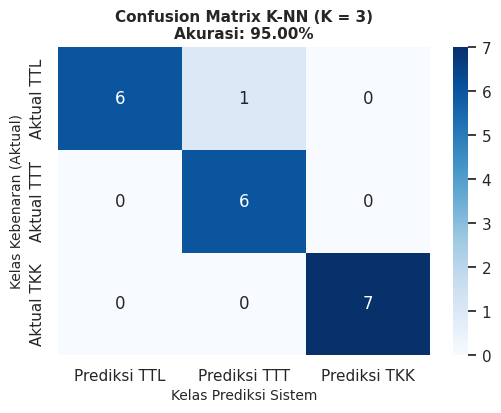

---------------------------------------------------------------------------
               HASIL EVALUASI MODEL K-NN UNTUK NILAI K = 5
---------------------------------------------------------------------------
Akurasi Sistem : 95.00%

Classification Report:
                           precision    recall  f1-score   support

    Teknik Tenaga Listrik       1.00      0.86      0.92         7
    Teknik Telekomunikasi       0.86      1.00      0.92         6
Teknik Komputer & Kendali       1.00      1.00      1.00         7

                 accuracy                           0.95        20
                macro avg       0.95      0.95      0.95        20
             weighted avg       0.96      0.95      0.95        20



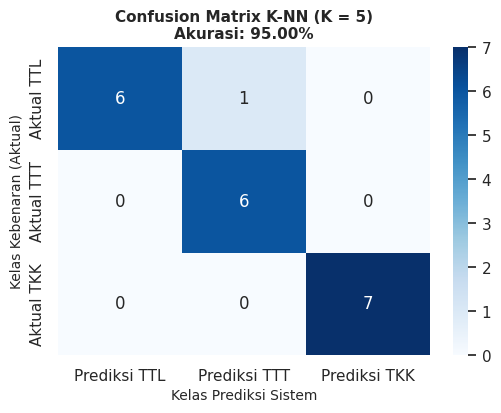

---------------------------------------------------------------------------
               HASIL EVALUASI MODEL K-NN UNTUK NILAI K = 7
---------------------------------------------------------------------------
Akurasi Sistem : 90.00%

Classification Report:
                           precision    recall  f1-score   support

    Teknik Tenaga Listrik       0.86      0.86      0.86         7
    Teknik Telekomunikasi       0.86      1.00      0.92         6
Teknik Komputer & Kendali       1.00      0.86      0.92         7

                 accuracy                           0.90        20
                macro avg       0.90      0.90      0.90        20
             weighted avg       0.91      0.90      0.90        20



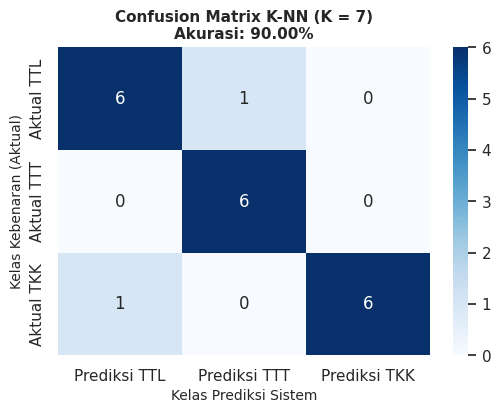

---------------------------------------------------------------------------
               HASIL EVALUASI MODEL K-NN UNTUK NILAI K = 9
---------------------------------------------------------------------------
Akurasi Sistem : 85.00%

Classification Report:
                           precision    recall  f1-score   support

    Teknik Tenaga Listrik       0.75      0.86      0.80         7
    Teknik Telekomunikasi       0.86      1.00      0.92         6
Teknik Komputer & Kendali       1.00      0.71      0.83         7

                 accuracy                           0.85        20
                macro avg       0.87      0.86      0.85        20
             weighted avg       0.87      0.85      0.85        20



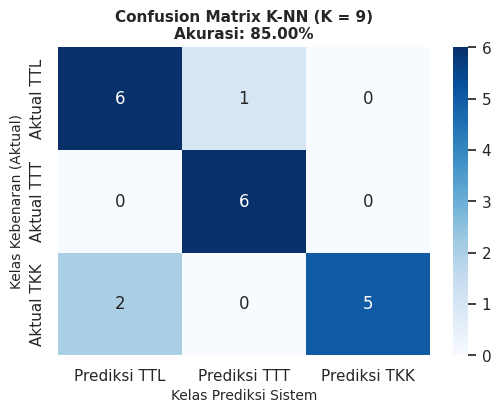

---------------------------------------------------------------------------
               HASIL EVALUASI MODEL K-NN UNTUK NILAI K = 11
---------------------------------------------------------------------------
Akurasi Sistem : 85.00%

Classification Report:
                           precision    recall  f1-score   support

    Teknik Tenaga Listrik       0.75      0.86      0.80         7
    Teknik Telekomunikasi       0.86      1.00      0.92         6
Teknik Komputer & Kendali       1.00      0.71      0.83         7

                 accuracy                           0.85        20
                macro avg       0.87      0.86      0.85        20
             weighted avg       0.87      0.85      0.85        20



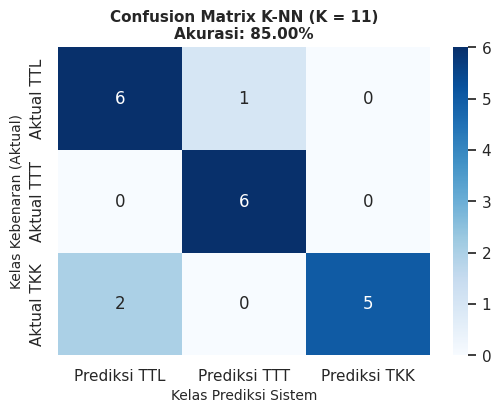


=== TABEL REKAPITULASI HASIL AKURASI PER K ===


,Nilai K,Akurasi Sistem (%),Prediksi Benar
0,K = 3,95.00%,19 / 20 Data
1,K = 5,95.00%,19 / 20 Data
2,K = 7,90.00%,18 / 20 Data
3,K = 9,85.00%,17 / 20 Data
4,K = 11,85.00%,17 / 20 Data


In [16]:
# TAHAP 6: KLASIFIKASI K-NN, EVALUASI & GENERATE CONFUSION MATRIX (K = 3, 5, 7, 9, 11)
label_kelas = ['Teknik Tenaga Listrik', 'Teknik Telekomunikasi', 'Teknik Komputer & Kendali']
variasi_k = [3, 5, 7, 9, 11]
rekap_performa = []

for k in variasi_k:
    # Model K-NN dengan weights='uniform' dan Euclidean Distance
    knn = KNeighborsClassifier(n_neighbors=k, weights='uniform', metric='euclidean')
    knn.fit(X_train, y_train)

    # Prediksi
    y_pred = knn.predict(X_test)

    # Hitung Akurasi dan Confusion Matrix
    acc = accuracy_score(y_test, y_pred) * 100
    cm = confusion_matrix(y_test, y_pred, labels=label_kelas)

    rekap_performa.append({
        'Nilai K': f"K = {k}",
        'Akurasi Sistem (%)': f"{acc:.2f}%",
        'Prediksi Benar': f"{np.trace(cm)} / {len(y_test)} Data"
    })

    print("-" * 75)
    print(f"               HASIL EVALUASI MODEL K-NN UNTUK NILAI K = {k}")
    print("-" * 75)
    print(f"Akurasi Sistem : {acc:.2f}%\n")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, labels=label_kelas, zero_division=0))

    # Visualisasi Heatmap Confusion Matrix
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Prediksi TTL', 'Prediksi TTT', 'Prediksi TKK'],
                yticklabels=['Aktual TTL', 'Aktual TTT', 'Aktual TKK'])

    plt.title(f'Confusion Matrix K-NN (K = {k})\nAkurasi: {acc:.2f}%', fontsize=11, fontweight='bold')
    plt.ylabel('Kelas Kebenaran (Aktual)', fontsize=10)
    plt.xlabel('Kelas Prediksi Sistem', fontsize=10)

    nama_gambar = f'confusion_matrix_K_{k}.png'
    plt.savefig(nama_gambar, dpi=300, bbox_inches='tight')
    plt.show()

# Display Tabel Rekapitulasi Akurasi
print("\n=== TABEL REKAPITULASI HASIL AKURASI PER K ===")
display(pd.DataFrame(rekap_performa))

              PROSES PENGUJIAN 5-FOLD CROSS VALIDATION                    

=== TABEL REKAPITULASI HASIL 5-FOLD CROSS VALIDATION ===


Parameter K,Fold 1 (%),Fold 2 (%),Fold 3 (%),Fold 4 (%),Fold 5 (%),Rata-Rata Akurasi (%),Standar Deviasi (%)
K = 3,90.0,65.0,90.0,85.0,85.0,83.0,9.27
K = 5,80.0,85.0,95.0,95.0,85.0,88.0,6.00
K = 7,75.0,75.0,85.0,95.0,85.0,83.0,7.48
K = 9,90.0,85.0,75.0,90.0,80.0,84.0,5.83
K = 11,85.0,90.0,75.0,90.0,85.0,85.0,5.48


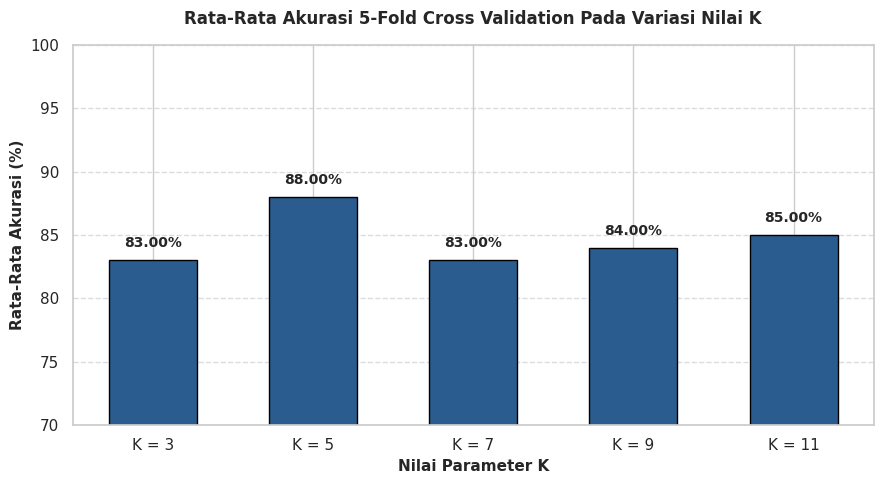

In [25]:
from sklearn.model_selection import KFold

# 1. Membaca Dataset Mentah Terbaru
nama_file = '/content/Data Mentah Penelitian Skripsi 5.csv'
df = pd.read_csv(nama_file, sep=';')

# 4. Inisialisasi 5-Fold Cross Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

k_values = [3, 5, 7, 9, 11]
rekap_cv = []

print("==========================================================================")
print("              PROSES PENGUJIAN 5-FOLD CROSS VALIDATION                    ")
print("==========================================================================")

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    # Mengukur akurasi pada tiap fold
    scores = cross_val_score(knn, X, y, cv=kf, scoring='accuracy')

    # Menyimpan hasil akurasi per fold
    row = {
        'Parameter K': f'K = {k}',
        'Fold 1 (%)': round(scores[0] * 100, 2),
        'Fold 2 (%)': round(scores[1] * 100, 2),
        'Fold 3 (%)': round(scores[2] * 100, 2),
        'Fold 4 (%)': round(scores[3] * 100, 2),
        'Fold 5 (%)': round(scores[4] * 100, 2),
        'Rata-Rata Akurasi (%)': round(scores.mean() * 100, 2),
        'Standar Deviasi (%)': round(scores.std() * 100, 2)
    }
    rekap_cv.append(row)

# 5. Membuat DataFrame Rekapitulasi Hasil Cross Validation
df_cv_results = pd.DataFrame(rekap_cv)

# Menampilkan Tabel di Google Colab
print("\n=== TABEL REKAPITULASI HASIL 5-FOLD CROSS VALIDATION ===")
display(HTML(df_cv_results.to_html(index=False)))

# 6. MEMBUAT GRAFIK BATANG HASIL RATA-RATA AKURASI CV
plt.figure(figsize=(9, 5))
bars = plt.bar(df_cv_results['Parameter K'], df_cv_results['Rata-Rata Akurasi (%)'], color='#2b5c8f', edgecolor='black', width=0.55)

# Menambahkan Label Angka di Atas Batang Grafik
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.8, f'{yval:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.title('Rata-Rata Akurasi 5-Fold Cross Validation Pada Variasi Nilai K', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Nilai Parameter K', fontsize=11, fontweight='bold')
plt.ylabel('Rata-Rata Akurasi (%)', fontsize=11, fontweight='bold')
plt.ylim(70, 100)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Menyimpan Gambar Grafik untuk Bab 4 / Lampiran
plt.savefig('grafik_cross_validation.png', dpi=300, bbox_inches='tight')
plt.show()

          TABEL HASIL PENGUJIAN STRATIFIED 5-FOLD CROSS VALIDATION        


Parameter K,Fold 1 (%),Fold 2 (%),Fold 3 (%),Fold 4 (%),Fold 5 (%),Rata-Rata Akurasi (%),Standar Deviasi (%)
K = 3,75.0,85.0,95.0,100.0,80.0,87.0,9.27
K = 5,75.0,80.0,90.0,100.0,90.0,87.0,8.72
K = 7,75.0,80.0,80.0,95.0,95.0,85.0,8.37
K = 9,80.0,85.0,90.0,90.0,80.0,85.0,4.47
K = 11,75.0,80.0,85.0,85.0,95.0,84.0,6.63


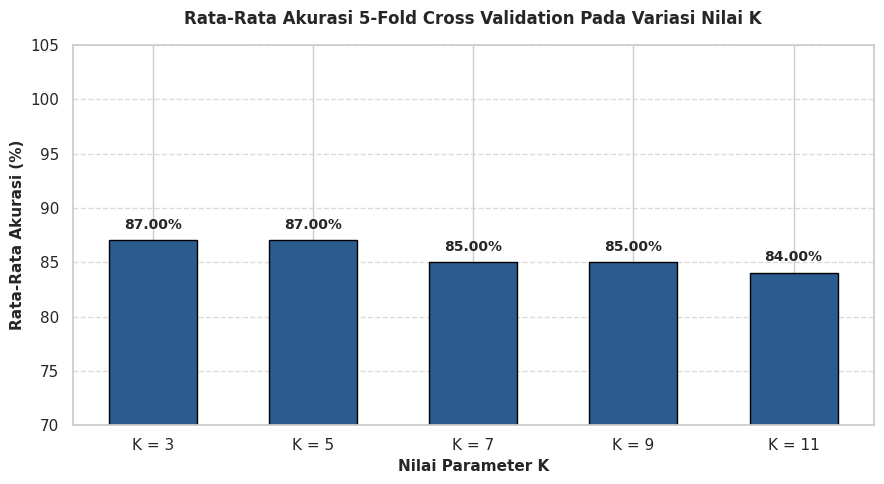


[INFO] Tabel hasil Cross Validation berhasil disimpan sebagai 'Hasil_5Fold_Cross_Validation.csv'


In [28]:

# ==============================================================================
# 4. PROSES STRATIFIED 5-FOLD CROSS VALIDATION
# ==============================================================================
# Mengunci pengacakan data menggunakan random_state=42 agar hasil konsisten
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

k_values = [3, 5, 7, 9, 11]
rekap_cv = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')

    # Menghitung skor akurasi pada tiap-tiap fold
    scores = cross_val_score(knn, X, y, cv=skf, scoring='accuracy')

    row = {
        'Parameter K': f'K = {k}',
        'Fold 1 (%)': round(scores[0] * 100, 2),
        'Fold 2 (%)': round(scores[1] * 100, 2),
        'Fold 3 (%)': round(scores[2] * 100, 2),
        'Fold 4 (%)': round(scores[3] * 100, 2),
        'Fold 5 (%)': round(scores[4] * 100, 2),
        'Rata-Rata Akurasi (%)': round(scores.mean() * 100, 2),
        'Standar Deviasi (%)': round(scores.std() * 100, 2)
    }
    rekap_cv.append(row)

# ==============================================================================
# 5. MENAMPILKAN TABEL REKAPITULASI CROSS VALIDATION
# ==============================================================================
df_cv_results = pd.DataFrame(rekap_cv)

print("==========================================================================")
print("          TABEL HASIL PENGUJIAN STRATIFIED 5-FOLD CROSS VALIDATION        ")
print("==========================================================================")
display(HTML(df_cv_results.to_html(index=False)))

# ==============================================================================
# 6. MEMBUAT GRAFIK BATANG HASIL CROSS VALIDATION
# ==============================================================================
plt.figure(figsize=(9, 5))
bars = plt.bar(df_cv_results['Parameter K'], df_cv_results['Rata-Rata Akurasi (%)'],
               color='#2b5c8f', edgecolor='black', width=0.55)

# Menambahkan persentase angka di atas tiap batang grafik
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.8, f'{yval:.2f}%',
             ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.title('Rata-Rata Akurasi 5-Fold Cross Validation Pada Variasi Nilai K', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Nilai Parameter K', fontsize=11, fontweight='bold')
plt.ylabel('Rata-Rata Akurasi (%)', fontsize=11, fontweight='bold')
plt.ylim(70, 105)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Menyimpan Gambar Grafik
plt.savefig('grafik_cross_validation.png', dpi=300, bbox_inches='tight')
plt.show()

# Menyimpan Tabel ke File CSV
df_cv_results.to_csv('Hasil_5Fold_Cross_Validation.csv', sep=';', index=False, decimal=',')
print("\n[INFO] Tabel hasil Cross Validation berhasil disimpan sebagai 'Hasil_5Fold_Cross_Validation.csv'")